# EDA — LLM Identification of Smart Contract Vulnerabilities

This notebook explores the dataset of smart contract audit repositories from platforms like **Code4rena** and **Sherlock**.

**Dataset layout:**
```
dataset/
  train/train/<project_hash>/   # 54 audit repos
  test/test/<project_hash>/     # 53 audit repos
```

Each project folder is a full git repo from a competitive audit, containing Solidity source, tests, and optional reports (`bot-report.json`, `scope.txt`, `4naly3er-report.md`).

**Sections**
1. Build Project-Level Metadata  
2. Dataset Overview  
3. Solidity File Counts  
4. Source Code Complexity  
5. Prize Pool Analysis  
6. Vulnerability Findings (from `bot-report.json`)  
7. Vulnerability Keyword Frequency  
8. Per-File Source Code Distribution  
9. Risky Feature Prevalence  
10. Summary

In [1]:
import os, re, json
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

BASE      = Path('../dataset')
TRAIN_DIR = BASE / 'train' / 'train'
TEST_DIR  = BASE / 'test'  / 'test'

print('Train projects:', sum(1 for p in TRAIN_DIR.iterdir() if p.is_dir()))
print('Test  projects:', sum(1 for p in TEST_DIR.iterdir()  if p.is_dir()))

Train projects: 54
Test  projects: 53


---
## 1. Build Project-Level Metadata

In [2]:
def parse_readme(path: Path) -> dict:
    info = {'platform': 'unknown', 'name': None, 'prize_pool': None}
    if not path.exists():
        return info
    text = path.read_text(errors='ignore')
    if 'code4rena' in text.lower() or 'c4 discord' in text.lower():
        info['platform'] = 'Code4rena'
    elif 'sherlock' in text.lower():
        info['platform'] = 'Sherlock'
    elif 'cantina' in text.lower():
        info['platform'] = 'Cantina'
    m = re.search(r'Total Prize Pool.*?\$?([\d,]+)', text)
    if m:
        info['prize_pool'] = int(m.group(1).replace(',', ''))
    m = re.search(r'^#\s+(.+)', text, re.M)
    if m:
        info['name'] = m.group(1).strip()
    return info


def tag_sol(sol: Path, proj_dir: Path) -> str:
    rel = str(sol.relative_to(proj_dir)).lower()
    if 'lib/' in rel or 'node_modules' in rel:
        return 'lib'
    if 'test/' in rel or sol.stem.endswith('.t'):
        return 'test'
    return 'src'


def scan_project(proj_dir: Path, split: str) -> dict:
    top_files = set(f.name for f in proj_dir.iterdir())
    sol_all   = list(proj_dir.rglob('*.sol'))
    tagged    = Counter(tag_sol(s, proj_dir) for s in sol_all)

    src_lines, src_funcs, src_mods = [], [], []
    for s in sol_all:
        if tag_sol(s, proj_dir) != 'src':
            continue
        try:
            c = s.read_text(errors='ignore')
            src_lines.append(c.count('\n'))
            src_funcs.append(len(re.findall(r'\bfunction\s+\w+', c)))
            src_mods.append(len(re.findall(r'\bmodifier\s+\w+', c)))
        except Exception:
            pass

    readme   = parse_readme(proj_dir / 'README.md')
    bot_json = proj_dir / 'bot-report.json'
    findings = []
    if bot_json.exists():
        with open(bot_json) as f:
            d = json.load(f)
        findings = d.get('findings', [])

    return {
        'split': split,
        'id':    proj_dir.name,
        **readme,
        'sol_total':        len(sol_all),
        'sol_src':          tagged['src'],
        'sol_test':         tagged['test'],
        'sol_lib':          tagged['lib'],
        'src_total_lines':  sum(src_lines),
        'src_avg_lines':    round(np.mean(src_lines), 1) if src_lines else 0,
        'src_max_lines':    max(src_lines, default=0),
        'src_total_funcs':  sum(src_funcs),
        'src_total_mods':   sum(src_mods),
        'has_bot_json':     bot_json.exists(),
        'has_bot_md':       (proj_dir / 'bot-report.md').exists(),
        'has_scope':        (proj_dir / 'scope.txt').exists(),
        'has_4naly':        (proj_dir / '4naly3er-report.md').exists(),
        'has_slither':      (proj_dir / 'slither.txt').exists() or (proj_dir / 'slither.config.json').exists(),
        'has_audit_dir':    'audit' in top_files or 'audits' in top_files,
        'has_discord':      'discord-export' in top_files,
        'num_findings':     len(findings),
        '_findings':        findings,   # kept for cell 6
    }

In [3]:
records = []
for split, base in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    for p in sorted(base.iterdir()):
        if p.is_dir() and not p.name.startswith('__'):
            records.append(scan_project(p, split))

df = pd.DataFrame([{k: v for k, v in r.items() if k != '_findings'} for r in records])
print(f'Shape: {df.shape}')
df.head()

Shape: (107, 22)


,split,id,platform,name,prize_pool,sol_total,sol_src,sol_test,sol_lib,src_total_lines,...,src_total_funcs,src_total_mods,has_bot_json,has_bot_md,has_scope,has_4naly,has_slither,has_audit_dir,has_discord,num_findings
0,train,1150ac69e096,Code4rena,Llama Audit Details,60500.0,61,21,34,6,4023,...,219,9,False,False,False,False,True,True,True,0
1,train,19000d572f72,Code4rena,Axelar contest details,NaN,24,22,2,0,2842,...,226,4,False,False,False,False,False,False,False,0
2,train,1aee004bafff,Code4rena,Arbitrum Security Council Elections audit details,90500.0,153,113,40,0,6826,...,420,12,False,False,False,False,False,True,False,0
3,train,1be7a2863fe1,Code4rena,Predy audit details,100000.0,1128,70,74,984,7631,...,361,8,False,True,True,True,True,False,True,0
4,train,22ad8fd6e044,Code4rena,Lens Protocol V2 audit details,85500.0,159,90,69,0,11183,...,603,20,False,False,False,False,False,True,True,0


---
## 2. Dataset Overview

In [4]:
print('=== Split counts ===')
print(df.groupby('split').size().to_string())

print('\n=== Platform distribution ===')
print(df.groupby(['split', 'platform']).size().unstack(fill_value=0).to_string())

train = df[df.split == 'train']
artefact_cols = ['has_bot_json','has_bot_md','has_scope','has_4naly','has_slither','has_audit_dir','has_discord']
print('\n=== Artefact coverage (train) ===')
print(train[artefact_cols].sum().to_string())

=== Split counts ===
split
test     53
train    54

=== Platform distribution ===
platform  Code4rena  Sherlock  unknown
split                                 
test             41         9        3
train            41        11        2

=== Artefact coverage (train) ===
has_bot_json      3
has_bot_md        6
has_scope         7
has_4naly         6
has_slither      10
has_audit_dir     6
has_discord      29


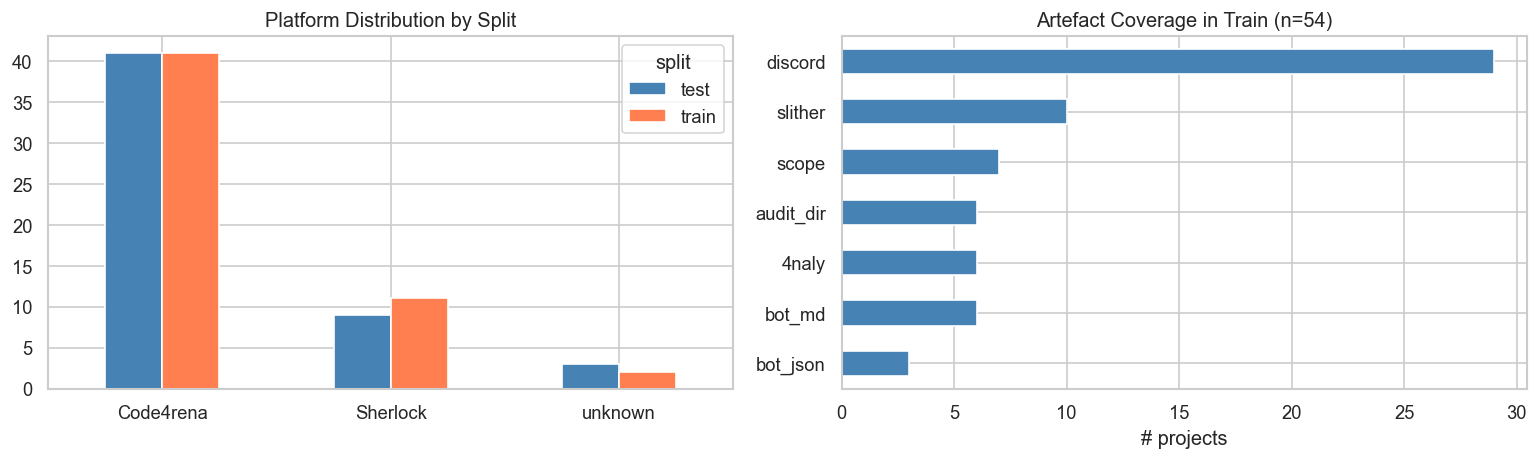

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Platform bar chart
plat = df.groupby(['split', 'platform']).size().unstack(fill_value=0)
plat.T.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Platform Distribution by Split')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='split')

# Artefact coverage
arts = train[artefact_cols].sum().sort_values(ascending=True)
arts.index = [c.replace('has_', '') for c in arts.index]
arts.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Artefact Coverage in Train (n={len(train)})')
axes[1].set_xlabel('# projects')

plt.tight_layout()
plt.show()

---
## 3. Solidity File Counts

In [6]:
print(df.groupby('split')[['sol_total', 'sol_src', 'sol_test', 'sol_lib']].describe().T)

split                  test        train
sol_total count   53.000000    54.000000
          mean   115.905660   142.925926
          std    167.200624   220.590105
          min      2.000000     1.000000
          25%     16.000000    36.250000
          50%     50.000000    68.500000
          75%    107.000000   142.250000
          max    752.000000  1128.000000
sol_src   count   53.000000    54.000000
          mean    46.358491    71.611111
          std     53.174276   104.074070
          min      1.000000     1.000000
          25%     12.000000    22.500000
          50%     31.000000    44.000000
          75%     60.000000    71.750000
          max    274.000000   556.000000
sol_test  count   53.000000    54.000000
          mean    16.320755    19.555556
          std     29.434264    24.336219
          min      0.000000     0.000000
          25%      0.000000     0.000000
          50%      4.000000     8.000000
          75%     17.000000    35.500000
          max   

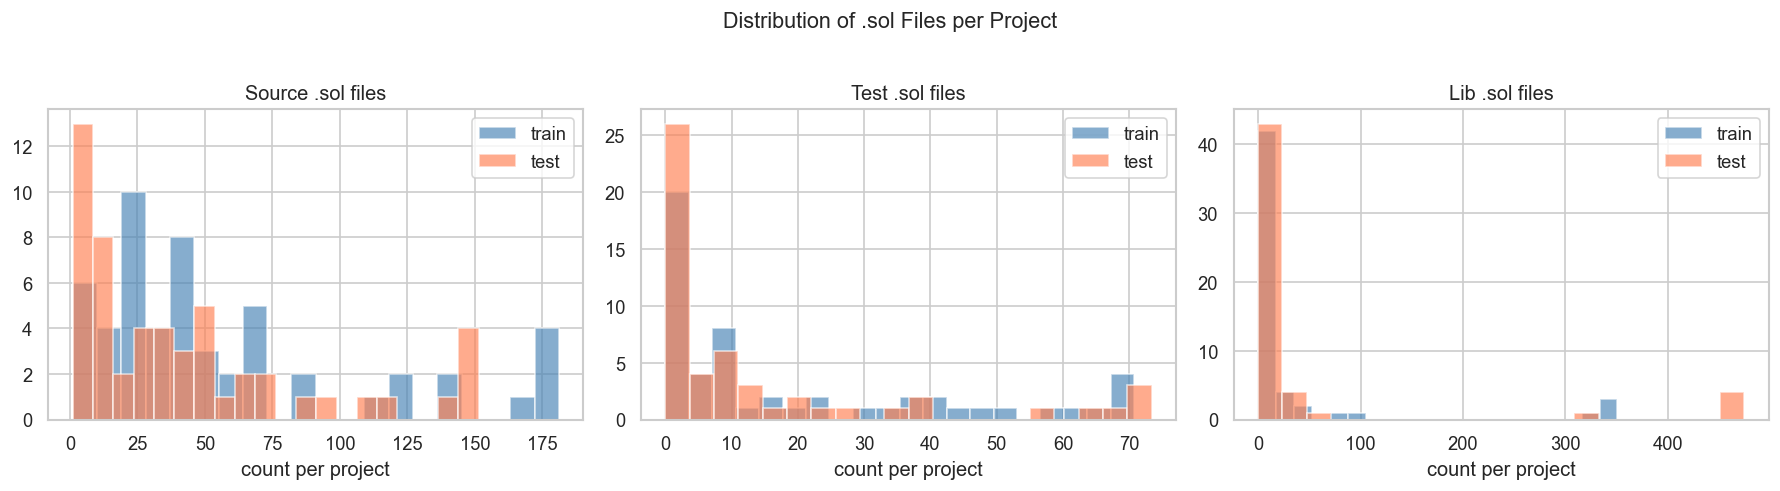

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
    ['sol_src', 'sol_test', 'sol_lib'],
    ['Source .sol files', 'Test .sol files', 'Lib .sol files']):
    for split, color in [('train', 'steelblue'), ('test', 'coral')]:
        vals = df.loc[df.split == split, col]
        ax.hist(vals.clip(upper=vals.quantile(0.95)), bins=20,
                alpha=0.65, label=split, color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('count per project')
    ax.legend()

plt.suptitle('Distribution of .sol Files per Project', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Source Code Complexity

In [8]:
print(df.groupby('split')[['src_total_lines','src_avg_lines','src_max_lines',
                            'src_total_funcs','src_total_mods']].describe().T)

split                          test          train
src_total_lines count     53.000000      54.000000
                mean    5989.377358    8657.000000
                std     9160.953753   17261.214318
                min       35.000000      28.000000
                25%      918.000000    2965.250000
                50%     3292.000000    5272.500000
                75%     7564.000000    7677.500000
                max    58765.000000  126877.000000
src_avg_lines   count     53.000000      54.000000
                mean     148.032075     157.074074
                std       97.257602     106.228401
                min       35.000000      20.500000
                25%      103.600000      96.675000
                50%      125.500000     127.650000
                75%      160.900000     187.775000
                max      601.000000     661.000000
src_max_lines   count     53.000000      54.000000
                mean     716.018868     813.851852
                std      464.57

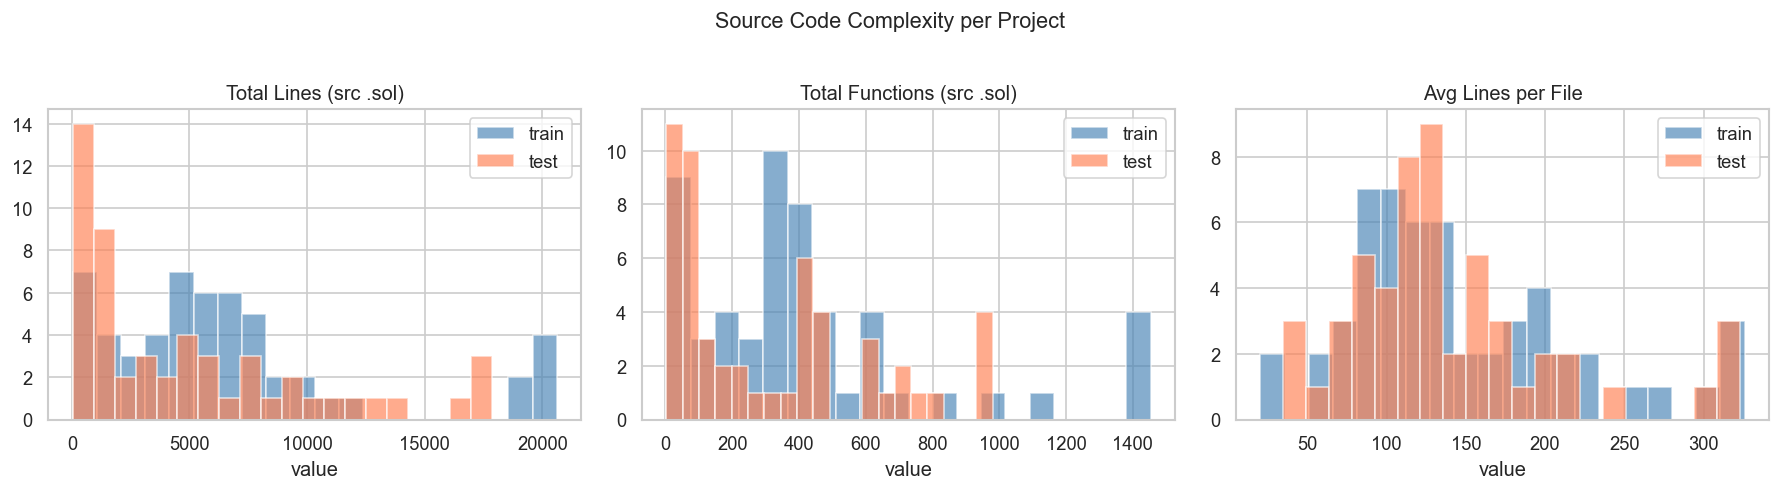

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ('src_total_lines', 'Total Lines (src .sol)'),
    ('src_total_funcs', 'Total Functions (src .sol)'),
    ('src_avg_lines',   'Avg Lines per File'),
]
for ax, (col, label) in zip(axes, pairs):
    for split, color in [('train', 'steelblue'), ('test', 'coral')]:
        vals = df.loc[df.split == split, col]
        ax.hist(vals.clip(upper=vals.quantile(0.95)), bins=20,
                alpha=0.65, label=split, color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('value')
    ax.legend()
plt.suptitle('Source Code Complexity per Project', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

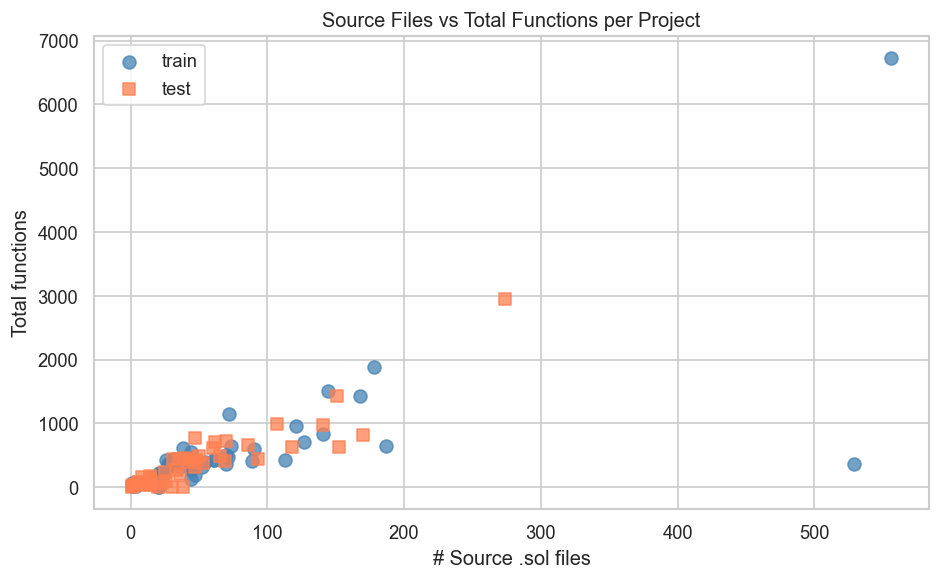

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for split, color, marker in [('train', 'steelblue', 'o'), ('test', 'coral', 's')]:
    sub = df[df.split == split]
    ax.scatter(sub.sol_src, sub.src_total_funcs,
               alpha=0.75, label=split, color=color, marker=marker, s=60)
ax.set_xlabel('# Source .sol files')
ax.set_ylabel('Total functions')
ax.set_title('Source Files vs Total Functions per Project')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Prize Pool Analysis (Code4rena)

In [11]:
c4 = df[(df.platform == 'Code4rena') & df.prize_pool.notna()].copy()
print(f'Projects with prize pool data: {len(c4)}')
print(c4.groupby('split')['prize_pool'].describe())

Projects with prize pool data: 36
       count          mean           std      min      25%      50%      75%  \
split                                                                          
test    17.0  65011.764706  56648.056921  14000.0  36500.0  40000.0  90500.0   
train   19.0  87768.421053  34752.570690  36500.0  65250.0  85500.0  90500.0   

            max  
split            
test   250000.0  
train  180500.0  


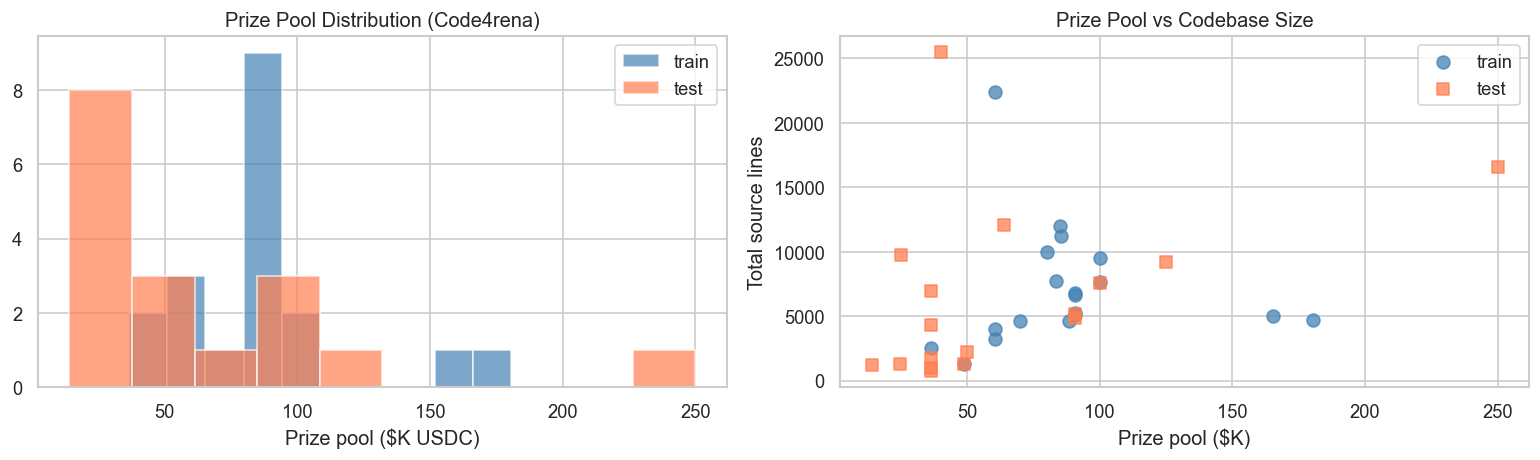

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for split, color in [('train', 'steelblue'), ('test', 'coral')]:
    sub = c4[c4.split == split]
    if not sub.empty:
        axes[0].hist(sub.prize_pool / 1000, bins=10, alpha=0.7,
                     label=split, color=color, edgecolor='white')
axes[0].set_title('Prize Pool Distribution (Code4rena)')
axes[0].set_xlabel('Prize pool ($K USDC)')
axes[0].legend()

for split, color, marker in [('train', 'steelblue', 'o'), ('test', 'coral', 's')]:
    sub = c4[c4.split == split]
    if not sub.empty:
        axes[1].scatter(sub.prize_pool / 1000, sub.src_total_lines,
                        alpha=0.75, label=split, color=color, marker=marker, s=60)
axes[1].set_xlabel('Prize pool ($K)')
axes[1].set_ylabel('Total source lines')
axes[1].set_title('Prize Pool vs Codebase Size')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Vulnerability Findings Analysis

Only **3 train projects** have structured `bot-report.json` files (the rest have markdown reports only).  
These 3 projects together contain **591 findings** across 5 severity levels.

In [13]:
SEV_ORDER  = ['Medium', 'Low', 'NonCritical', 'Gas', 'Disputed']
SEV_COLORS = {
    'Medium': '#e74c3c', 'Low': '#f39c12',
    'NonCritical': '#3498db', 'Gas': '#2ecc71', 'Disputed': '#95a5a6'
}

finding_rows = []
for r in records:
    if r['split'] != 'train':
        continue
    for f in r['_findings']:
        finding_rows.append({
            'project':        r['id'],
            'protocol':       r['name'],
            'severity':       f.get('severity'),
            'title':          f.get('title', ''),
            'num_instances':  len(f.get('instances', [])),
            'description_len': len(f.get('description', '') or ''),
        })

fdf = pd.DataFrame(finding_rows)
print(f'Total findings: {len(fdf)}')
print()
print(fdf.severity.value_counts().to_string())

Total findings: 591

severity
NonCritical    286
Gas            162
Low             77
Disputed        60
Medium           6


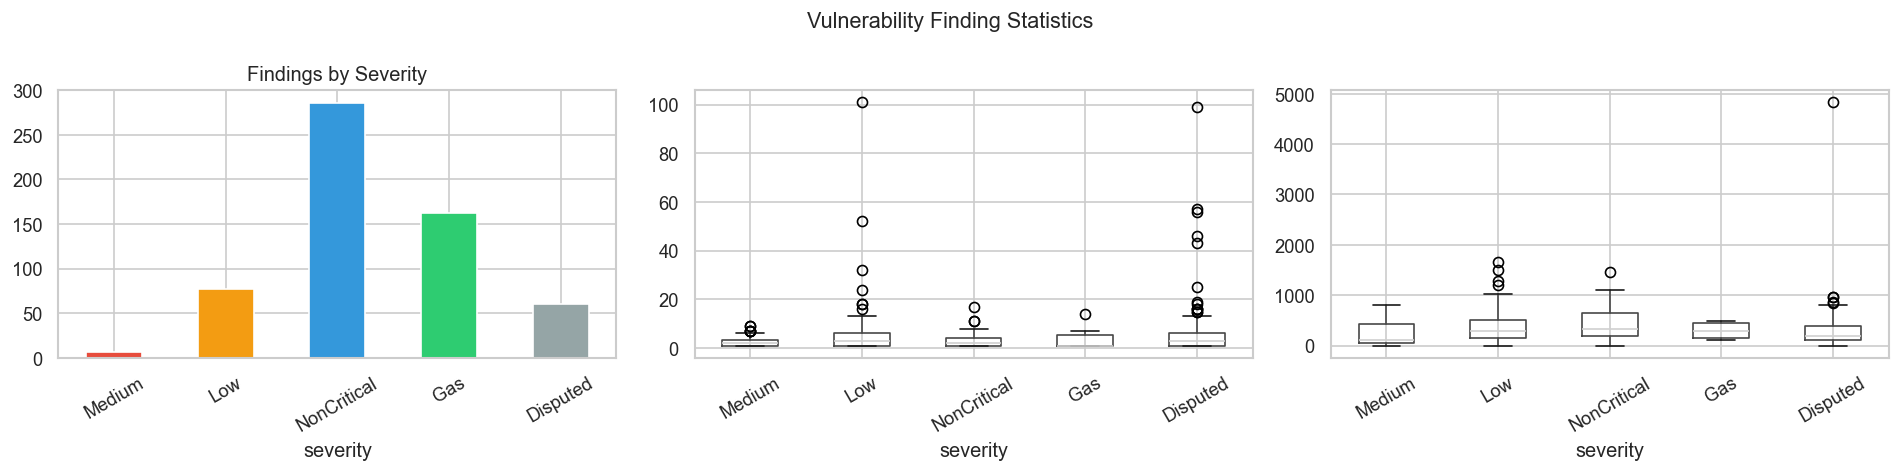

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# severity bar
sev_counts = fdf.severity.value_counts().reindex(SEV_ORDER, fill_value=0)
colors = [SEV_COLORS.get(s, 'grey') for s in sev_counts.index]
sev_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Findings by Severity')
axes[0].tick_params(axis='x', rotation=30)

# instances per finding by severity
ordered = [s for s in SEV_ORDER if s in fdf.severity.unique()]
fdf.boxplot(column='num_instances', by='severity', ax=axes[1],
            positions=range(len(ordered)))
axes[1].set_title('Instances per Finding (by Severity)')
axes[1].set_xticklabels(ordered, rotation=30)
plt.sca(axes[1]); plt.title('')

# description length by severity
fdf.boxplot(column='description_len', by='severity', ax=axes[2],
            positions=range(len(ordered)))
axes[2].set_title('Description Length (chars) by Severity')
axes[2].set_xticklabels(ordered, rotation=30)
plt.sca(axes[2]); plt.title('')

plt.suptitle('Vulnerability Finding Statistics', fontsize=13)
plt.tight_layout()
plt.show()

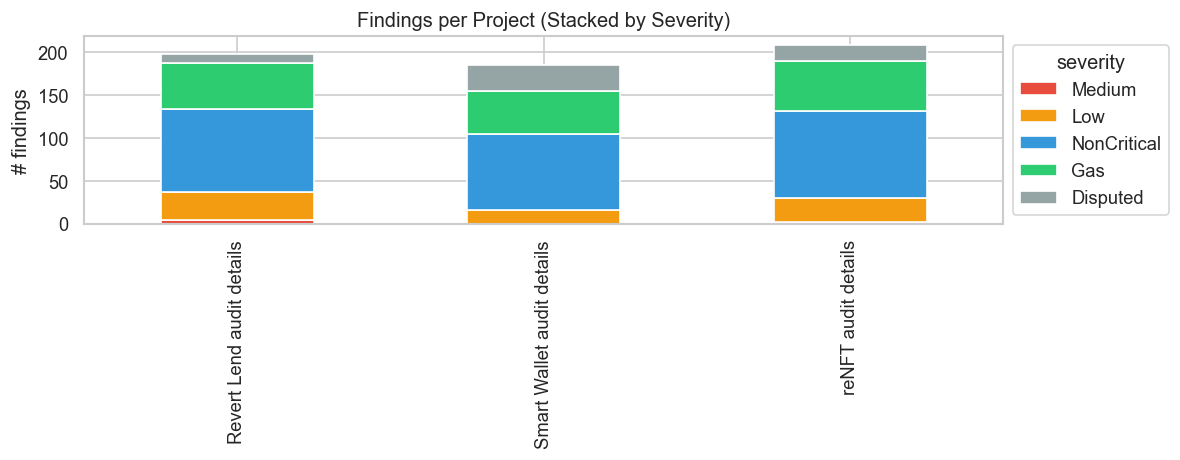


Avg instances per finding by severity:
severity
Medium         4.2
Low            3.1
NonCritical    5.1
Gas            5.4
Disputed       2.7


In [15]:
proj_sev = fdf.groupby(['protocol', 'severity']).size().unstack(fill_value=0)
proj_sev = proj_sev.reindex(columns=[c for c in SEV_ORDER if c in proj_sev.columns])
proj_sev.plot(kind='bar', stacked=True, figsize=(10, 4),
              color=[SEV_COLORS[c] for c in proj_sev.columns])
plt.title('Findings per Project (Stacked by Severity)')
plt.xlabel('')
plt.ylabel('# findings')
plt.legend(title='severity', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print('\nAvg instances per finding by severity:')
print(fdf.groupby('severity')['num_instances'].mean().reindex(SEV_ORDER).round(1).to_string())

---
## 7. Vulnerability Keyword Frequency in Finding Titles

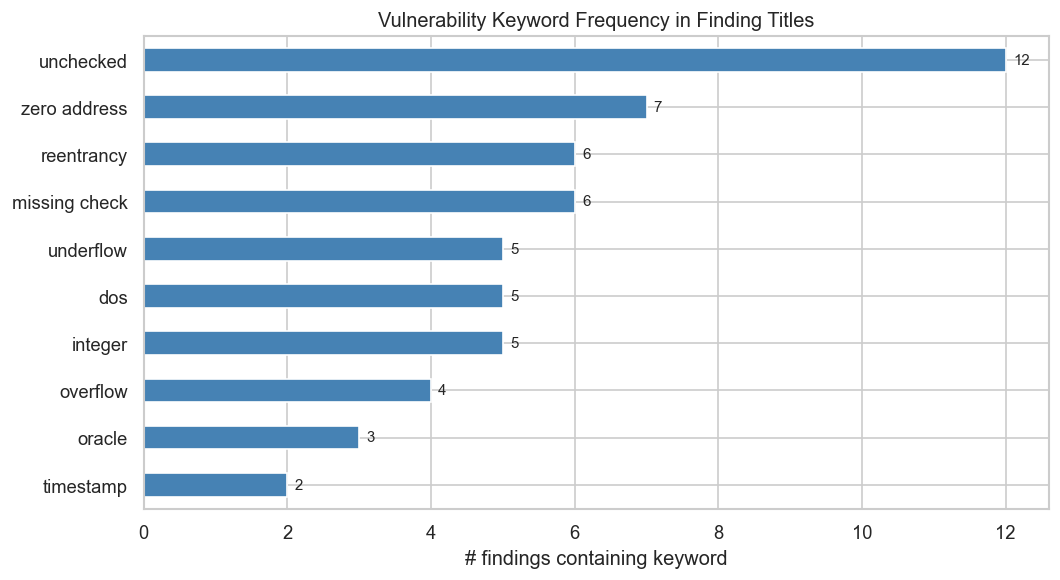

In [17]:
VULN_KEYWORDS = [
    'reentrancy', 'overflow', 'underflow', 'oracle', 'flash loan',
    'front-run', 'dos', 'denial of service', 'integer', 'unchecked',
    'uninitialized', 'access control', 'delegate', 'timestamp',
    'missing check', 'zero address', 'rounding', 'slippage',
]

titles_lower = fdf['title'].str.lower()
kw_counts = {kw: int(titles_lower.str.contains(kw, regex=False).sum()) for kw in VULN_KEYWORDS}
kw_series = pd.Series(kw_counts).sort_values(ascending=True)
kw_series = kw_series[kw_series > 0]

fig, ax = plt.subplots(figsize=(9, 5))
kw_series.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Vulnerability Keyword Frequency in Finding Titles')
ax.set_xlabel('# findings containing keyword')
for bar, val in zip(ax.patches, kw_series.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Per-File Source Code Distribution

In [18]:
file_rows = []
for proj_dir in sorted(TRAIN_DIR.iterdir()):
    if not proj_dir.is_dir() or proj_dir.name.startswith('__'):
        continue
    for sol in proj_dir.rglob('*.sol'):
        kind = tag_sol(sol, proj_dir)
        if kind == 'lib':
            continue
        try:
            c = sol.read_text(errors='ignore')
            file_rows.append({
                'project':          proj_dir.name,
                'file':             sol.name,
                'kind':             kind,
                'lines':            c.count('\n'),
                'funcs':            len(re.findall(r'\bfunction\s+\w+', c)),
                'modifiers':        len(re.findall(r'\bmodifier\s+\w+', c)),
                'events':           len(re.findall(r'\bevent\s+\w+', c)),
                'custom_errors':    len(re.findall(r'\berror\s+\w+', c)),
                'has_external':     bool(re.search(r'\bexternal\b', c)),
                'has_payable':      bool(re.search(r'\bpayable\b', c)),
                'has_delegatecall': bool(re.search(r'\bdelegatecall\b', c)),
                'has_assembly':     bool(re.search(r'\bassembly\b', c)),
                'has_unchecked':    bool(re.search(r'\bunchecked\b', c)),
            })
        except Exception:
            pass

fdf2   = pd.DataFrame(file_rows)
src_f  = fdf2[fdf2.kind == 'src']
test_f = fdf2[fdf2.kind == 'test']
print(f'Source files: {len(src_f)} | Test files: {len(test_f)}')
print()
print(src_f[['lines', 'funcs', 'modifiers', 'events', 'custom_errors']].describe().round(1))

Source files: 3274 | Test files: 1029

        lines   funcs  modifiers  events  custom_errors
count  3274.0  3274.0     3274.0  3274.0         3274.0
mean    142.8     8.8        0.2     1.2            0.7
std     220.3    12.5        0.8     3.3            2.8
min       4.0     0.0        0.0     0.0            0.0
25%      27.0     2.0        0.0     0.0            0.0
50%      65.0     4.0        0.0     0.0            0.0
75%     157.8    11.0        0.0     1.0            0.0
max    1783.0   121.0        8.0    34.0           58.0


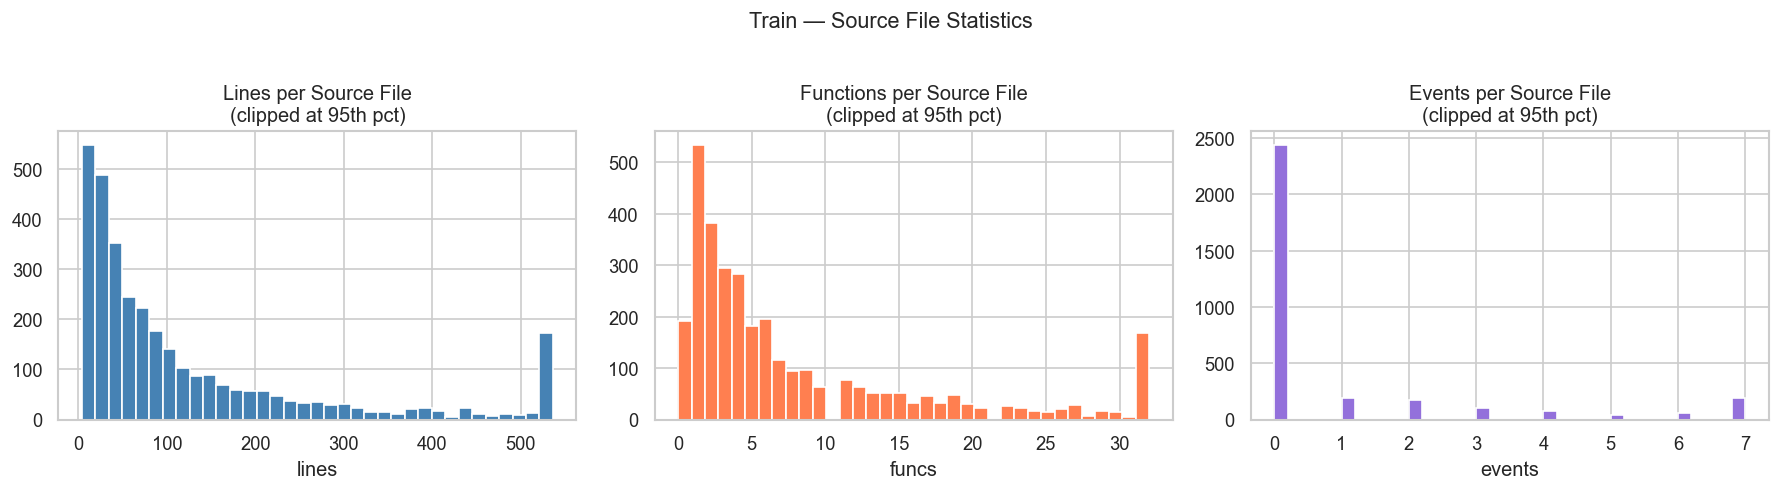

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, label in [
    (axes[0], 'lines',  'steelblue', 'Lines per Source File'),
    (axes[1], 'funcs',  'coral',     'Functions per Source File'),
    (axes[2], 'events', 'mediumpurple', 'Events per Source File'),
]:
    clip95 = src_f[col].quantile(0.95)
    src_f[col].clip(upper=clip95).hist(bins=35, ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{label}\n(clipped at 95th pct)')
    ax.set_xlabel(col)

plt.suptitle('Train — Source File Statistics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Risky Feature Prevalence

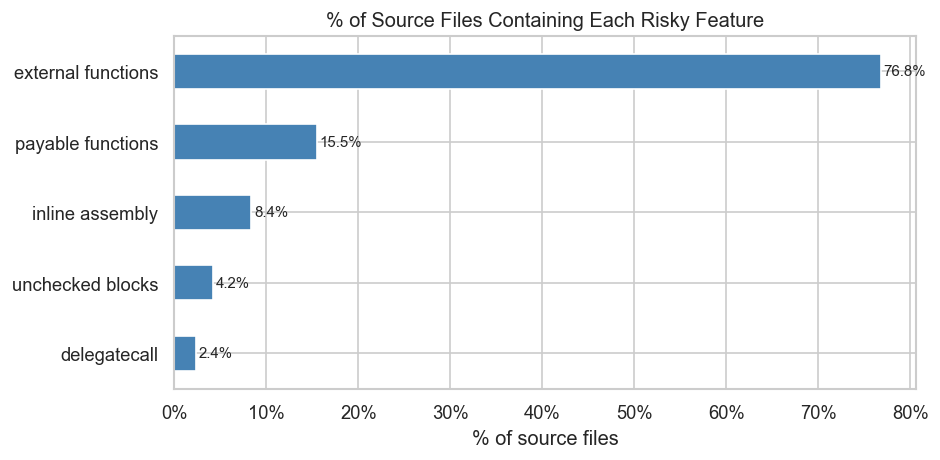

Raw counts:
  external functions             2513  (76.8%)
  payable functions               506  (15.5%)
  unchecked blocks                137  (4.2%)
  inline assembly                 274  (8.4%)
  delegatecall                     78  (2.4%)


In [20]:
risky = {
    'external functions': src_f.has_external.sum(),
    'payable functions':  src_f.has_payable.sum(),
    'unchecked blocks':   src_f.has_unchecked.sum(),
    'inline assembly':    src_f.has_assembly.sum(),
    'delegatecall':       src_f.has_delegatecall.sum(),
}
risky_pct = pd.Series({k: v / len(src_f) * 100 for k, v in risky.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
risky_pct.plot(kind='barh', ax=ax, color='steelblue')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('% of Source Files Containing Each Risky Feature')
ax.set_xlabel('% of source files')
for bar, val in zip(ax.patches, risky_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Raw counts:')
for k, v in risky.items():
    print(f'  {k:<30} {v:4d}  ({v/len(src_f)*100:.1f}%)')

---
## 10. Summary

In [21]:
train_df = df[df.split == 'train']
test_df  = df[df.split == 'test']

print('=' * 58)
print('DATASET SUMMARY')
print('=' * 58)
print(f"{'Split':<35} Train      Test")
print('-' * 58)
print(f"{'# projects':<35} {len(train_df):<10} {len(test_df)}")
print(f"{'Code4rena projects':<35} {(train_df.platform=='Code4rena').sum():<10} {(test_df.platform=='Code4rena').sum()}")
print(f"{'Sherlock projects':<35} {(train_df.platform=='Sherlock').sum():<10} {(test_df.platform=='Sherlock').sum()}")
print()
print('--- Source Code (train) ---')
print(f"  Total .sol source files:          {train_df.sol_src.sum()}")
print(f"  Total .sol test files:            {train_df.sol_test.sum()}")
print(f"  Total source lines:               {train_df.src_total_lines.sum():,}")
print(f"  Total functions:                  {train_df.src_total_funcs.sum():,}")
print(f"  Avg source files per project:     {train_df.sol_src.mean():.1f}")
print(f"  Avg source lines per project:     {train_df.src_total_lines.mean():.0f}")
print()
print('--- Artefact Coverage (train) ---')
for col in artefact_cols:
    n = train_df[col].sum()
    print(f"  {col.replace('has_', ''):<28} {n:3d} / {len(train_df)}")
print()
print('--- Findings (bot-report.json, train) ---')
print(f"  Projects with JSON report:        {train_df.has_bot_json.sum()}")
print(f"  Total findings:                   {len(fdf)}")
for sev in SEV_ORDER:
    cnt = (fdf.severity == sev).sum()
    print(f"    {sev:<25} {cnt:3d}")
print()
print('--- Risky Feature Prevalence (train src files) ---')
for k, v in risky.items():
    print(f"  {k:<30} {v:4d} ({v/len(src_f)*100:.1f}%)")
print('=' * 58)

DATASET SUMMARY
Split                               Train      Test
----------------------------------------------------------
# projects                          54         53
Code4rena projects                  41         41
Sherlock projects                   11         9

--- Source Code (train) ---
  Total .sol source files:          3867
  Total .sol test files:            1056
  Total source lines:               467,478
  Total functions:                  28,901
  Avg source files per project:     71.6
  Avg source lines per project:     8657

--- Artefact Coverage (train) ---
  bot_json                       3 / 54
  bot_md                         6 / 54
  scope                          7 / 54
  4naly                          6 / 54
  slither                       10 / 54
  audit_dir                      6 / 54
  discord                       29 / 54

--- Findings (bot-report.json, train) ---
  Projects with JSON report:        3
  Total findings:                   591
    Medi